# LLM Trees - Decision Trees through LLMs

#### Members:
- Jasmine Jassi, 500970682
- Sam Olamazadeh, 500963965
- Tharindu(Tharu) Yakkala A. Don, 501220016
####  Emails:
- tyakkala@torontomu.ca
- jasmine.jassi@torontomu.ca

# Introduction:

#### Problem Description:

This project aims to implement zero-shot prompting to generate decision-trees using a pre-trained LLM, namely Gemini 2.5 Flash, to observe how the model utilizes its world knowledge from pre-training for predictive modeling with 5 different datasets. This study follows the paper '"OH LLM, I'm Asking Thee, Please Give Me a Decision Tree": Zero-Shot Decision Tree Induction and Embedding with Large Language Models' by Knauer et. al.

#### Context of the Problem:

Training large language models, depending on the task and dataset at hand, can prove to be both computationally and literally expensive. In addition, with proprietary datasets, it can be a privacy issue to input sensitive details into public models, limiting the amount of data that can be used in training these models. Such a situation where data is scarce can be referred to as a "low-data regime" [1]. However, the general knowledge that these pre-trained models have can still be applicable or useful for generating models that can then be used for proprietary or smaller datasets, removing the issue for privacy as no training data is passed to the model; only feature names. The aspect of "knowledge distillation" to generate decision trees goes hand-in-hand with applying in-context learning, creating an approach to generate "intrinsically interpretable machine learning models" [1]. While the paper extends to embeddings analysis, this project focuses on the induction component (generating and evaluating the decision trees through zero-shot prompting).

#### Limitation About other Approaches:

Previous studies involved generating features without training data [1] and a few labeled examples [2] using LLMs. However, this project (and paper) focuses on building actual models that can be used to further interpret data without any training required.

#### Solution:

Rather than giving state-of-art LLMs access to proprietary data as examples, only important feature names are provided and the LLM is zero-shot prompted to create the best possible decision tree based on the knowledge it has. Similar to the paper, we use the decision trees to classify 5 different datasets and analyze the classification reports for accuray, precision and F1 values.

# Background

| Reference |Explanation |  Dataset/Input | Weakness |
|-----------|------------|----------------|----------|
| Nam et al. [2] | They proposed OCTree, a framework that uses LLMs to iteratively generate new column <br> features for tabular prediction tasks. <br> The LLM is prompted to return a feature name and generation rule <br> (using no training data in LLM prompt itself). <br> New feature used to augment data and combined data used to train decision tree. | Multiple tabular classification/regression benchmarks <br> (including Kaggle datasets); <br> CART algorithm and Llama 2 7B (fine-tuned) model | Evaluating generated features can be time-consuming if model requires <br> extensive training but the authors note this issue can be mitigated by <br> generating features with simpler prediction model first and then <br> using them in the target model |
| Han et al. [3] | They use FeatLLM (in-context learning framework) that uses LLMs to as feature engineers <br> to create optimal input dataset for tabular tasks. LLM is prompted with few labeled <br> examples and extracts rules associated with each class. The rules are used to create <br> binary features as inputs for a linear model to estimate likelihood of each class. | 13 different tabular datasets in low-shot regimes; <br> FeatLLM uses GPT-3.5 | Only generated binary features (limited representations); <br> Automated parsing via LLM error rates higher for data with many <br> categorical features; <br> Biases and misinformation embedded in the prior knowledge of LLMs should <br> be considered |
| Knauer et al. [1] | They use zero-shot prompting to generate decision trees without any training data. <br> They also create embeddings from these decision trees for <br> downstream models. | Small-sized tabular datasets from public Penn Machine <br> Learning Benchmarks (PMLB); <br> 4 state-of-the-art LLMs and 5 ML baselines | Focused on small-sized tabular datasets (question whether results <br> extend in other settings); <br> Used a simple prompting template (whether it captures all the complexity); <br> Can use more powerful LLMs (biases and prior knowledge of LLMs should be considered) <br> |


# Methodology

We used the same datasets used by Knauer et al. where they only utilized various datasets that were less than or equal to 500 rows. All datasets are classification based and have a binary target. The authors chose these datasets because the feature names were not ambiguous, and could easily be understood by an LLM along with some descriptions of them. Originally the paper used 15 public datasets, however we reduced that down to 5; acl, bankruptcy, boxing1, boxing2, and colic.

We created a prompt using the same initial prompt used by Knauer et al, but a more simplified single prompt method. The prompting strategy used by them typically consists of multiple prompts where LLMs are prompted in sequential steps. First the decision tree sturcture is extracted, and then the LLM is asked to create a function which the features can be provided to, that outputs a classification and also a set of features that represents the decision logic within the treee (Knauer et al., 2025). The unified system prompt contains the following, a personal section that tells the LLM it is a domain expert capable of generating Decision trees without any direct training data, and instead use it's vast internal training data, and two sequence of steps for outputting the decision internally and then using that to generate the function. For the user prompt, the LLM is given a short description of the dataset's domain and background, along with the desciption of the feature names, data types and expected input/output format of each feature/label (Knauer et al., 2025).

<p align="center">
    <img src="src/figures/llm_flow.png" alt="LLM dt extraction flow" width="500"/>
</p>

Initially we used a platform called Open Router that provided some state of the art open source models through free apis, however after initial testing we found that endpoint to be quite slow. We found that there is a free api on colab that allows you to use Gemini 2.5 Flash without an api key, the system and user prompt were then combined into one main prompt, where it was fed into Google Colab's free AI API. From these prompts the model is prompted five times per dataset, to extract five various decision tree classifiers. These outputs from the model are then used as the backbone of the classifers for which we test the metrics, such as, f1-score, accuracy, recall, and precision of each decision tree function generated by Gemini. As there could be various in the use of the parameters in each funciton, we will then edit some parts of these functions to be more uniform, however, the decision logic outputted by the LLM will remain. We also assess the ensemble capabilities by utilizing a voting style ensemble, where the final label is the most classified label. Since we do not have a train/test split, as the decision tree logic is extracted directly from the LLM, we will use all the rows of each dataset as the test set. As a result we have 25 decision tree functions in total, where for each dataset there is 5. Below is a simplified version of how each function works and an example output.
<p align="center">
    <img src="src/figures/func_example_full.png" alt="Function example" width="300"/>
</p>

# Implementation

### LLM Tree Extraciton

The extraction is done through colab's google.colab.ai api, which provides a free api.

**Sample outputs**

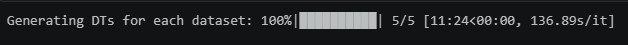

The following are the output function logic from the LLM

![Alternate text ](src/figures/sample_output.png "Title of the figure, location is simply the directory of the notebook")

![Alternate text ](src/figures/sample_output2.png "Title of the figure, location is simply the directory of the notebook")

### Tree Evaluation

In [2]:
from src.Evaluators import (
    evaluate_bankruptcy,
    evaluate_boxing1,
    evaluate_boxing2,
    evaluate_colic,
    evaluate_creditscore
)

from src.plotter import plot_emb_results

**NOTE** You need a API key (its free) from https://ux.priorlabs.ai/home

1. You can create an account for free, and then udner Licenses menu accpet license for TabPFN models.
2. Copy your token from API Keys menu.
2. Create a .env file and enter a line like this

Ensure that the .env is in the same directory level as this notebook
```
TABPFN_TOKEN = "your_token"
```

#### Bankruptcy

BANKRUPTCY DATASET - Zero-Shot Decision Tree Evaluation
Dataset size: 50 | Bankrupt(1)=25, Non-Bankrupt(0)=25

  Model_0: Accuracy=0.5333  Precision=0.5446  Recall=0.5500  F1=0.5249
  Model_1: Accuracy=0.6000  Precision=0.5500  Recall=0.5500  F1=0.5500
  Model_2: Accuracy=0.6000  Precision=0.5500  Recall=0.5500  F1=0.5500
  Model_3: Accuracy=0.8667  Precision=0.8500  Recall=0.8500  F1=0.8500
  Model_4: Accuracy=0.8000  Precision=0.8125  Recall=0.8500  F1=0.7964

  Ensemble (Majority Voting): Accuracy=0.6667  Precision=0.6389  Recall=0.6500  F1=0.6411

              precision    recall  f1-score   support

Non-Bankrupt       0.78      0.70      0.74        10
    Bankrupt       0.50      0.60      0.55         5

    accuracy                           0.67        15
   macro avg       0.64      0.65      0.64        15
weighted avg       0.69      0.67      0.67        15



Testing embeddings: 100%|██████████| 9/9 [01:18<00:00,  8.68s/it]


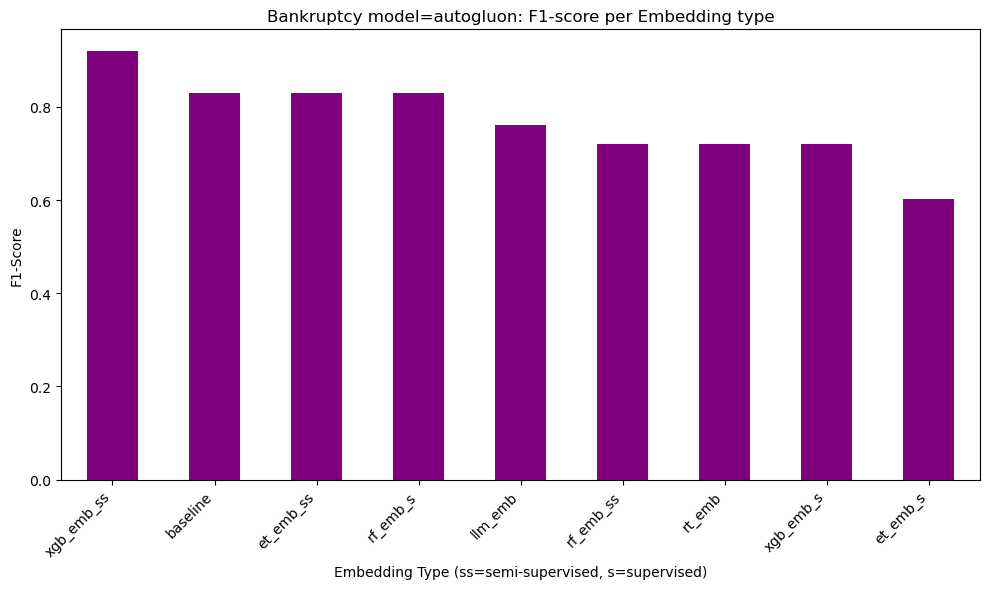

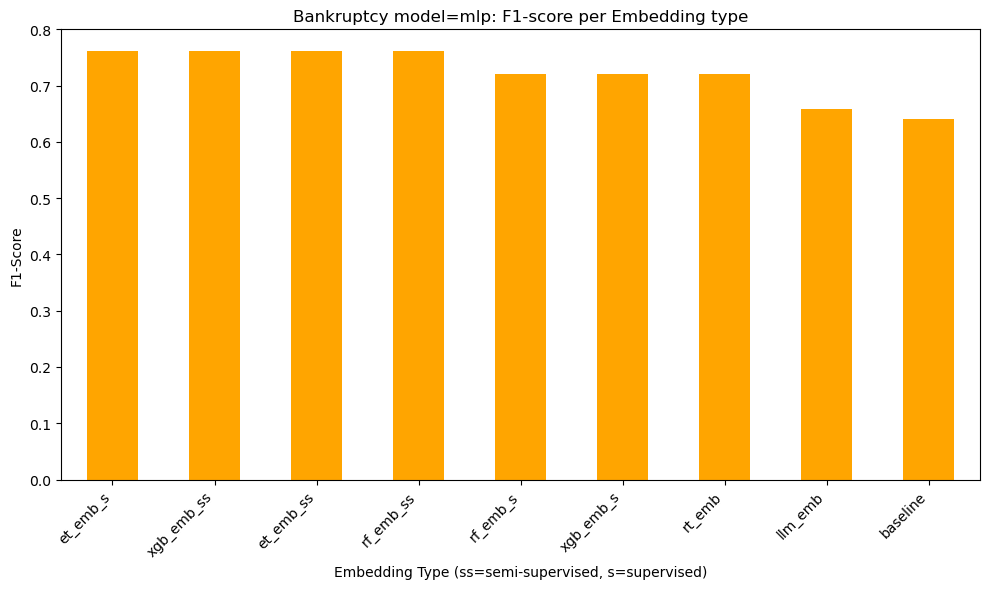

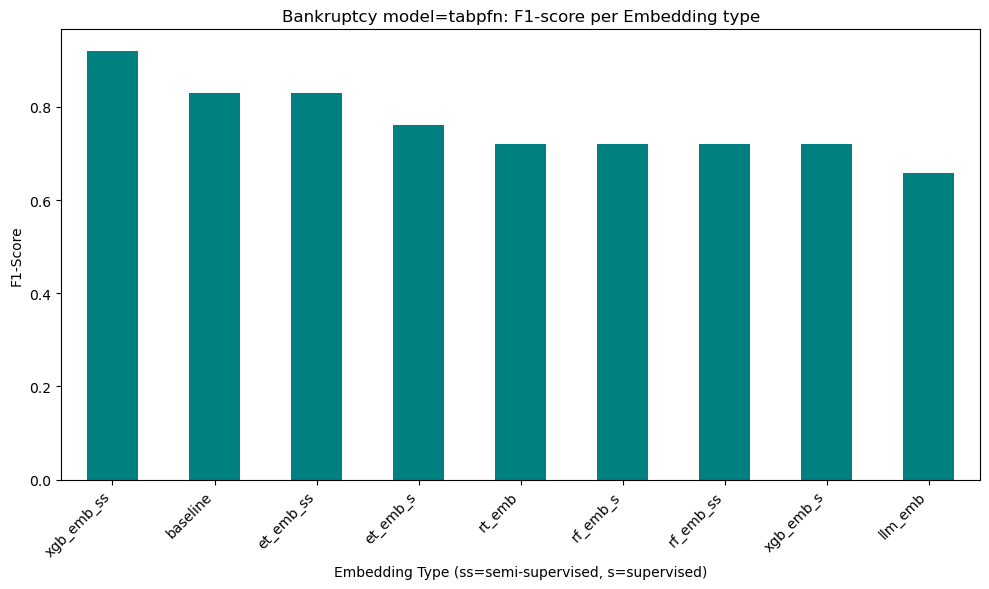

In [4]:
# Code cells
emb_df = evaluate_bankruptcy.evaluate()
plot_emb_results(emb_df, dataset="Bankruptcy")

#### Boxing1

BOXING1 (Lewis vs Holyfield) - Zero-Shot Decision Tree Evaluation
Dataset size: 120 | Lewis(1)=78, Holyfield(0)=42

  Model_0: Accuracy=0.5556  Precision=0.2778  Recall=0.5000  F1=0.3571
  Model_1: Accuracy=0.6667  Precision=0.6667  Recall=0.6500  F1=0.6494
  Model_2: Accuracy=0.6944  Precision=0.7222  Recall=0.6687  F1=0.6630
  Model_3: Accuracy=0.5556  Precision=0.2778  Recall=0.5000  F1=0.3571
  Model_4: Accuracy=0.5278  Precision=0.4394  Recall=0.4813  F1=0.3923

  Ensemble (Majority Voting): Accuracy=0.5556  Precision=0.5000  Recall=0.2778  F1=0.3571

              precision    recall  f1-score   support

   Holyfield       0.00      0.00      0.00        16
       Lewis       0.56      1.00      0.71        20

    accuracy                           0.56        36
   macro avg       0.28      0.50      0.36        36
weighted avg       0.31      0.56      0.40        36



Testing embeddings: 100%|██████████| 9/9 [01:17<00:00,  8.61s/it]


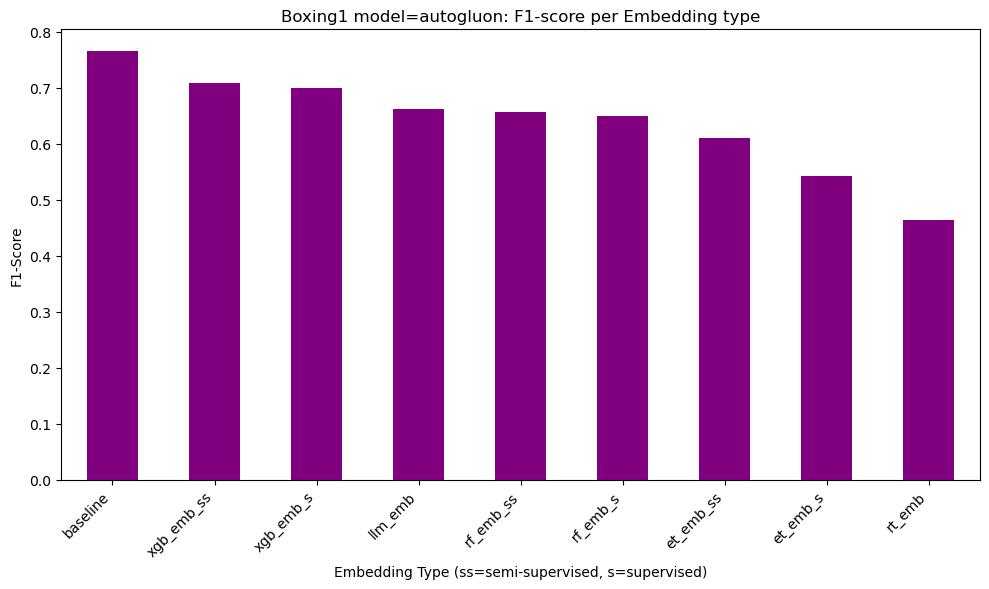

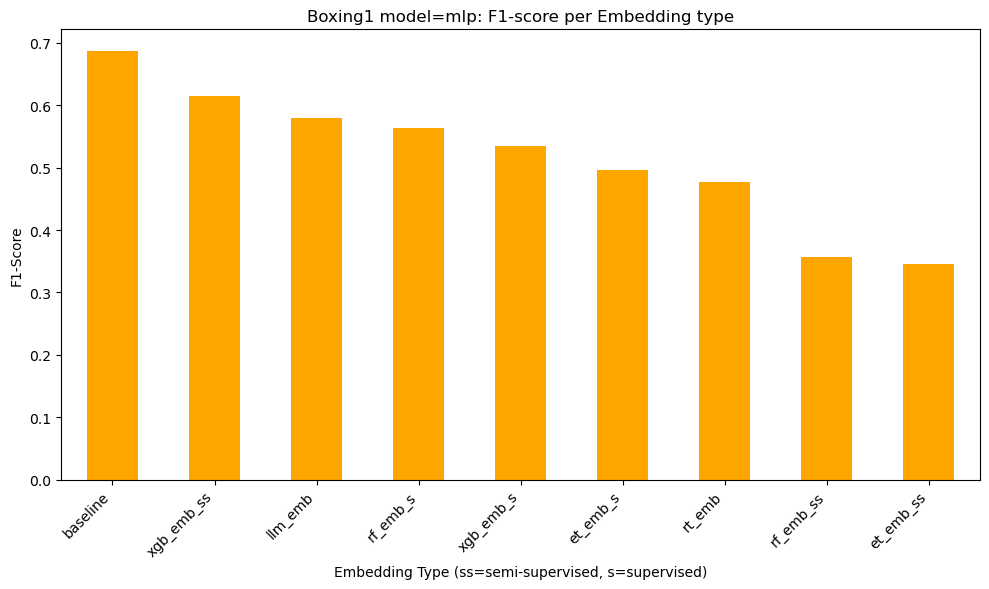

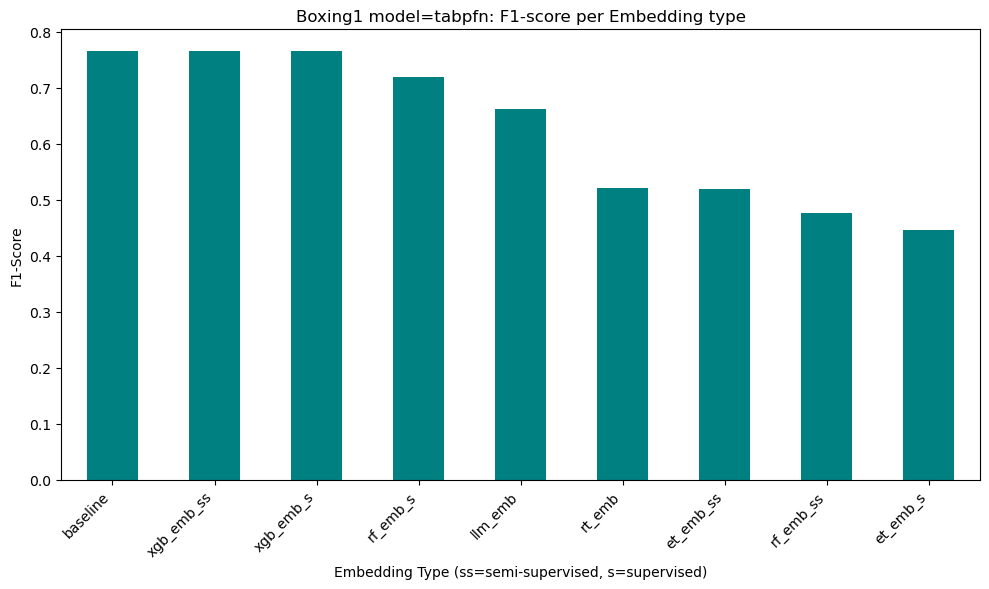

In [5]:
# Code cells
emb_df = evaluate_boxing1.evaluate()
plot_emb_results(emb_df, dataset="Boxing1")

#### Boxing 2

BOXING2 (Trinidad vs de la Hoya) - Zero-Shot Decision Tree Evaluation
Dataset size: 132 | de la Hoya(1)=71, Trinidad(0)=61

  Model_0: Accuracy=0.4500  Precision=0.4978  Recall=0.4987  F1=0.4133
  Model_1: Accuracy=0.4500  Precision=0.4978  Recall=0.4987  F1=0.4133
  Model_2: Accuracy=0.6500  Precision=0.6466  Recall=0.6496  F1=0.6465
  Model_3: Accuracy=0.6250  Precision=0.6422  Recall=0.5742  F1=0.5423
  Model_4: Accuracy=0.5750  Precision=0.5625  Recall=0.5614  F1=0.5616

  Ensemble (Majority Voting): Accuracy=0.6000  Precision=0.5908  Recall=0.5908  F1=0.5908

              precision    recall  f1-score   support

    Trinidad       0.53      0.53      0.53        17
  de la Hoya       0.65      0.65      0.65        23

    accuracy                           0.60        40
   macro avg       0.59      0.59      0.59        40
weighted avg       0.60      0.60      0.60        40



Testing embeddings: 100%|██████████| 9/9 [01:16<00:00,  8.52s/it]


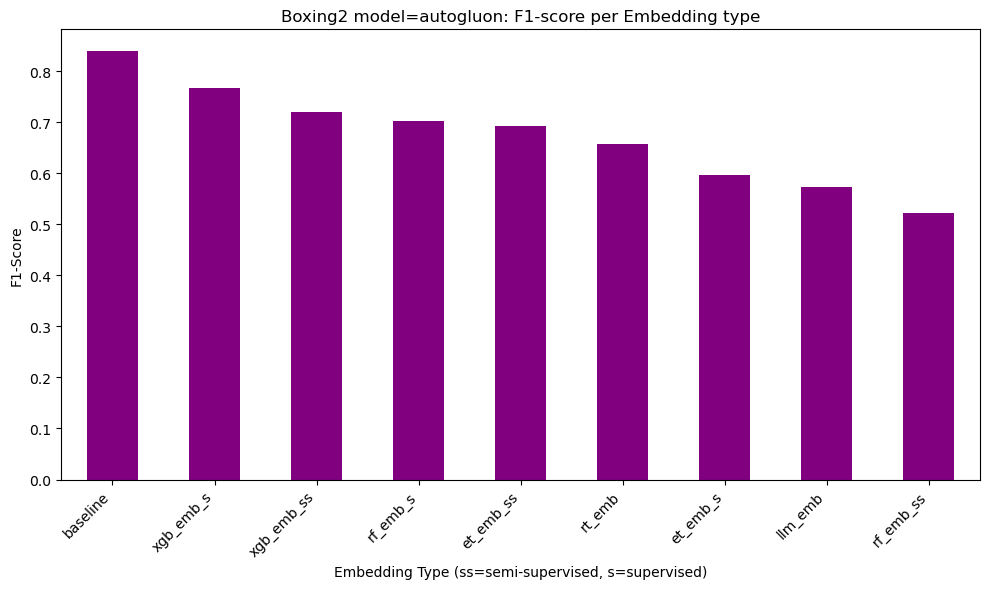

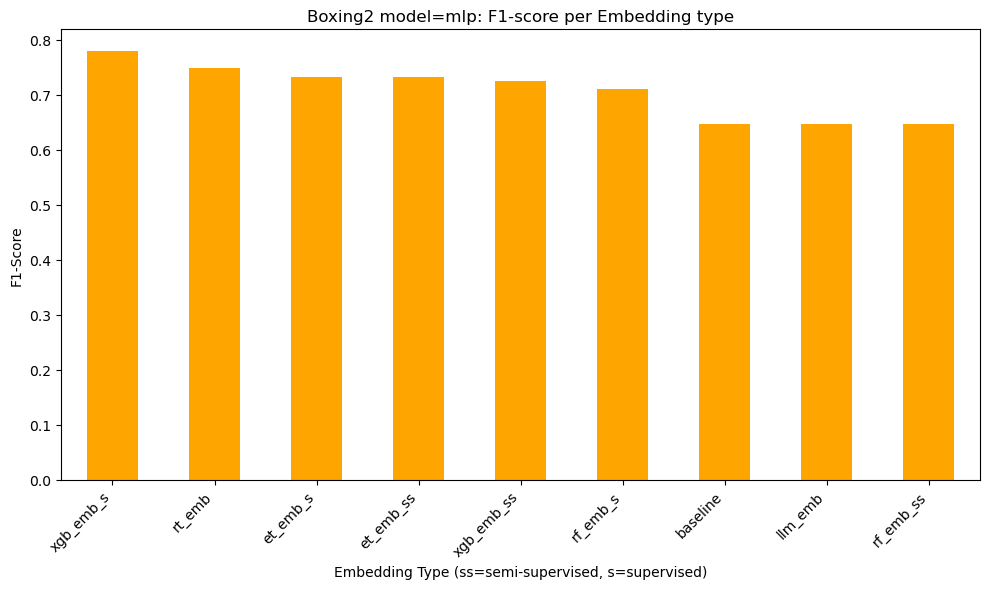

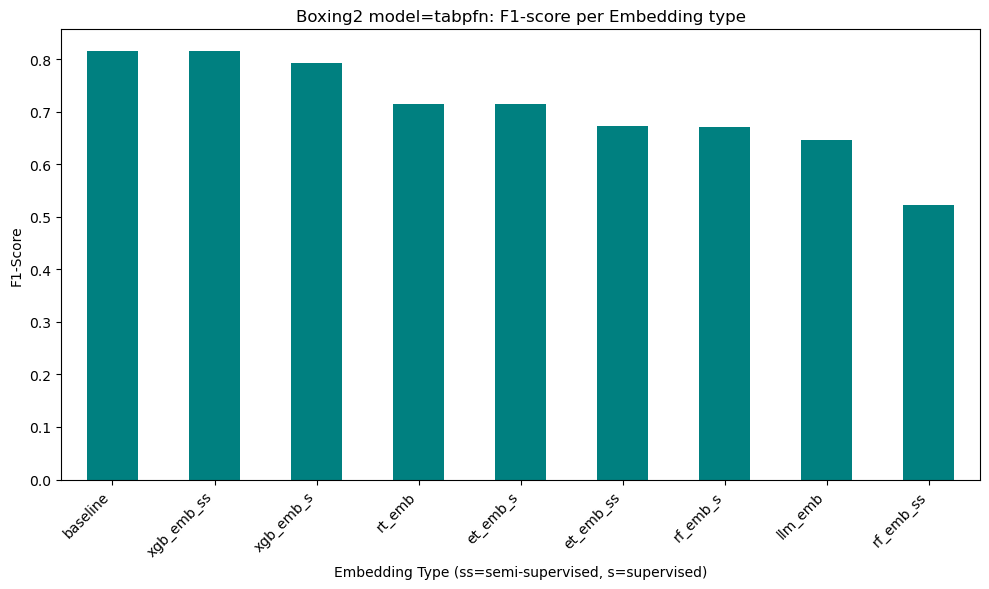

In [6]:
# Code cells
emb_df = evaluate_boxing2.evaluate()
plot_emb_results(emb_df, dataset="Boxing2")

#### Colic

COLIC (Horse) DATASET - Zero-Shot Decision Tree Evaluation
Dataset size: 368 | Surgical(1)=232, Non-Surgical(0)=136

  Model_0: Accuracy=0.7027  Precision=0.6948  Recall=0.6329  F1=0.6343
  Model_1: Accuracy=0.6847  Precision=0.6973  Recall=0.5934  F1=0.5770
  Model_2: Accuracy=0.7027  Precision=0.6948  Recall=0.6329  F1=0.6343
  Model_3: Accuracy=0.7027  Precision=0.6948  Recall=0.6329  F1=0.6343
  Model_4: Accuracy=0.5766  Precision=0.6445  Recall=0.6340  F1=0.5753

  Ensemble (Majority Voting): Accuracy=0.7027  Precision=0.6329  Recall=0.6948  F1=0.6343

              precision    recall  f1-score   support

Non-Surgical       0.68      0.37      0.48        41
    Surgical       0.71      0.90      0.79        70

    accuracy                           0.70       111
   macro avg       0.69      0.63      0.63       111
weighted avg       0.70      0.70      0.68       111



Testing embeddings: 100%|██████████| 9/9 [02:42<00:00, 18.03s/it]


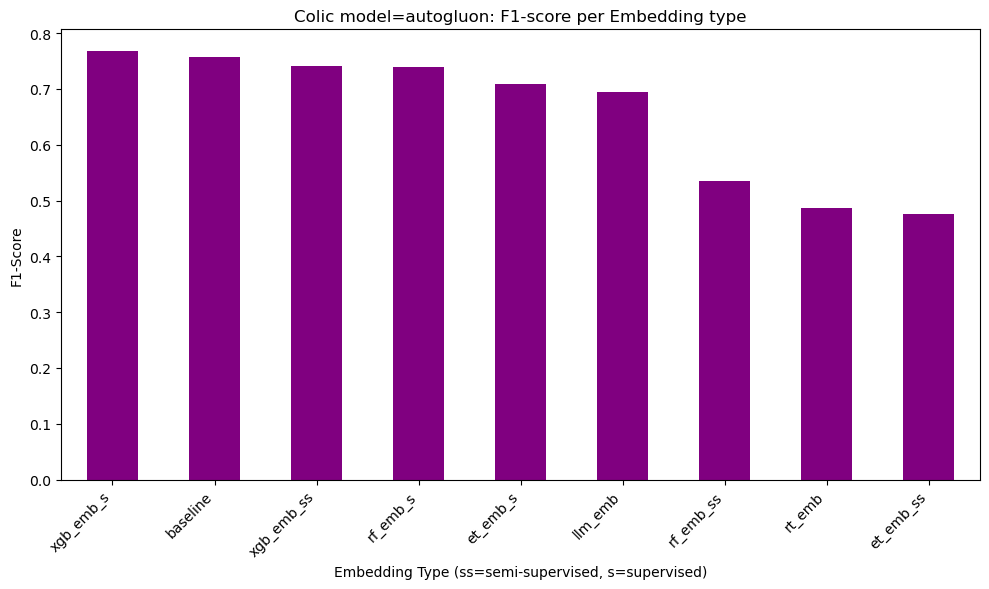

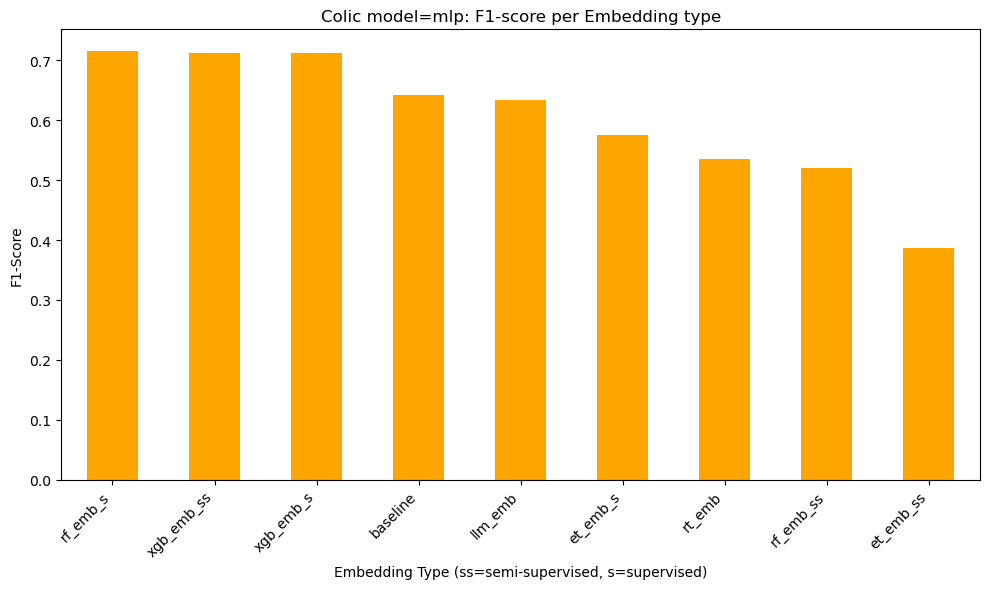

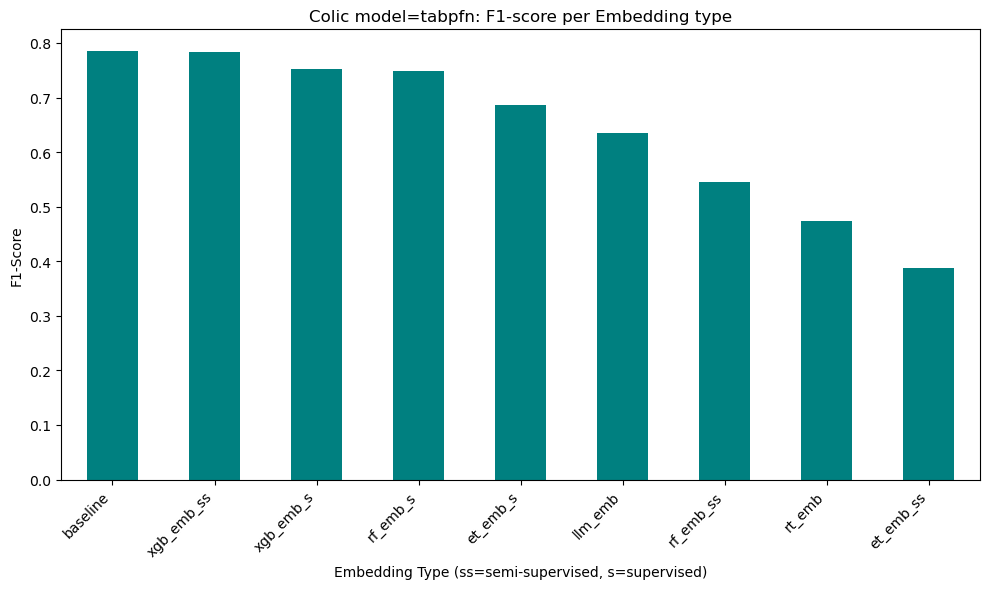

In [3]:
# Code cells
emb_df = evaluate_colic.evaluate()
plot_emb_results(emb_df, dataset="Colic")

#### CreditScore

CREDIT SCORE DATASET - Zero-Shot Decision Tree Evaluation
Dataset size: 100 | Accepted(1)=73, Rejected(0)=27

  Model_0: Accuracy=0.5000  Precision=0.7000  Recall=0.6250  F1=0.4857
  Model_1: Accuracy=0.5333  Precision=0.7083  Recall=0.6500  F1=0.5249
  Model_2: Accuracy=0.5667  Precision=0.6196  Recall=0.6250  F1=0.5662
  Model_3: Accuracy=0.4667  Precision=0.6923  Recall=0.6000  F1=0.4444
  Model_4: Accuracy=0.5333  Precision=0.7083  Recall=0.6500  F1=0.5249

  Ensemble (Majority Voting): Accuracy=0.5333  Precision=0.6500  Recall=0.7083  F1=0.5249

              precision    recall  f1-score   support

    Rejected       0.42      1.00      0.59        10
    Accepted       1.00      0.30      0.46        20

    accuracy                           0.53        30
   macro avg       0.71      0.65      0.52        30
weighted avg       0.81      0.53      0.50        30



Testing embeddings: 100%|██████████| 9/9 [01:15<00:00,  8.42s/it]


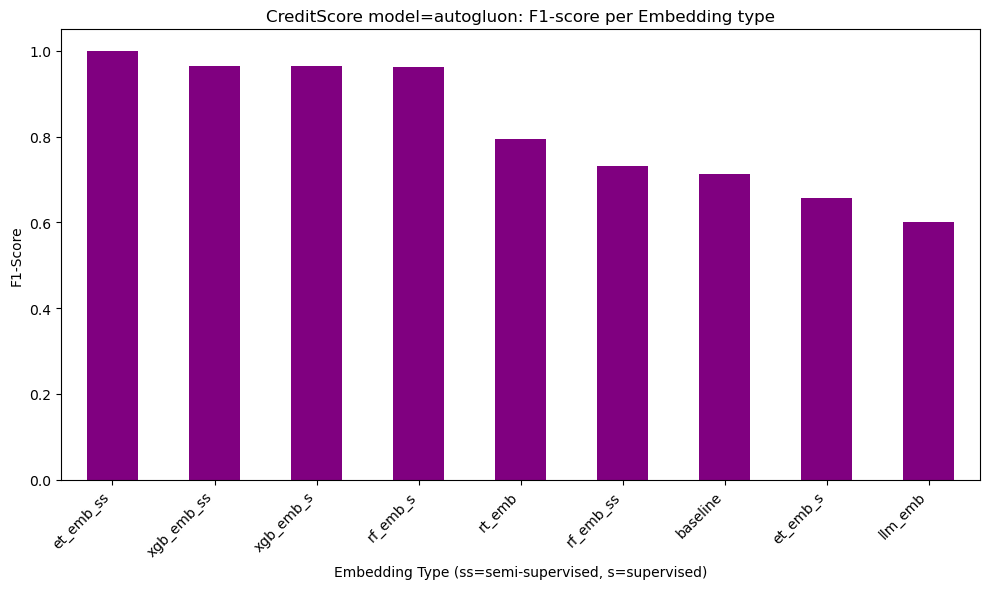

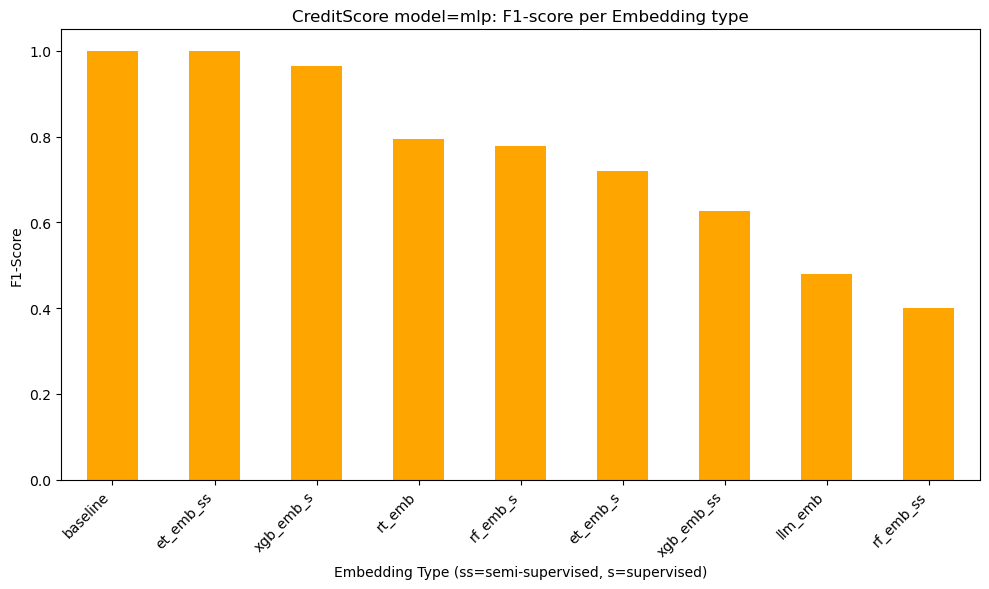

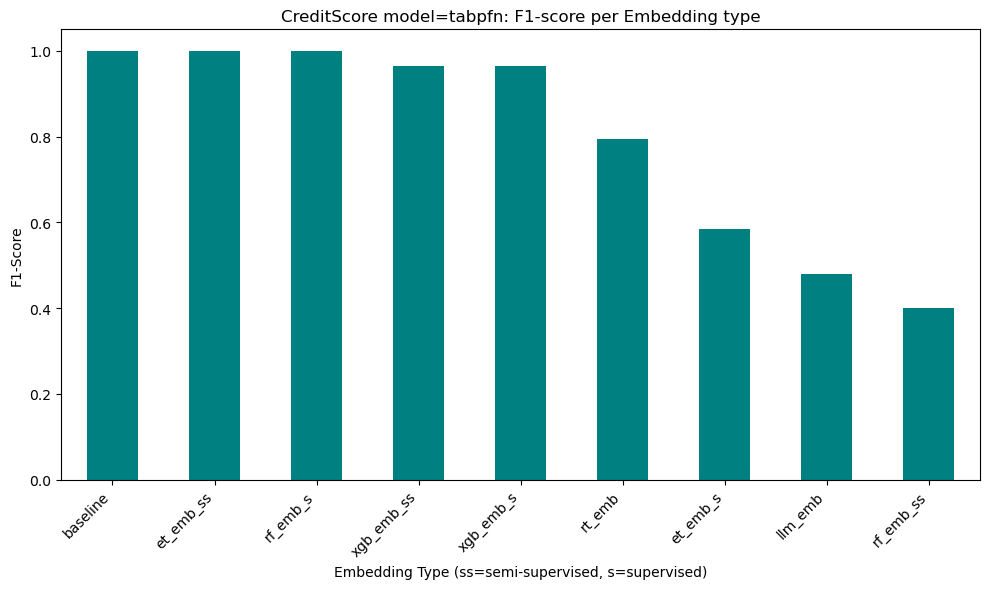

In [7]:
# Code cells
emb_df = evaluate_creditscore.evaluate()
plot_emb_results(emb_df, dataset="CreditScore")

# Conclusion and Future Direction

Generally, we find that the ensemble of the 5 models doesn’t always result in a better accuracy compared to individual models themselves. This is due to the fact that of the 5 models generated by the LLM there is typically going to be some that do a lot more poorly than others and vice versa. Typically, when there is less variance among the model metrics, the ensemble results are more stable. For instance, on the colic dataset, the accuracy(72%) and f1 score (71%) is around the range of the metrics of the individual models for that dataset. However, for the bankruptcy dataset, there is a model that outperforms all of them with an accuracy of 86% and f1 score of 81% compared to the ensemble accuracy of 68% and f1 of 68%. This is due the fact that most of the other models performed much worse. If we set a baseline of the model guessing every time it would have 50% accuracy, then all except the creditscore dataset perform much higher than this random baseline. This could indicate that LLMs do have the inherent ability to distill its knowledge of the vast amount of information that it was trained upon, to apply its own internal reasoning to generate the decision tree logic, along with sample functions.

The limitations of these results also stem from the fact that we couldn’t really compare it to a decision tree from sci kit learn, because those models just always get 100% accuracy on small datasets. Even if we were to split the datasets, into train and test, the datasets themselves are quite small ranging from 50-368. This was also mentioned by Knauer et al., because the results of the models are based on small datasets, so there is still work to be done to compare it to larger datasets. Other future steps would be to utilize the features that the models can also output based on the decision nodes, we think that these could be beneficial in order to perhaps to see if they increase model accuracy. We also only compared the results from one LLM, so utilizing more frontier models such as GPT, Claude, ande even open source models such as, Qwen could be done to compare different models and their ability to distill their information.



# References:

[1]:  Knauer, R., Koddenbrock, M., Wallsberger, R., Brisson, N. M., Duda, G. N., Falla, D., Evans, D. W., & Rodner, E. (2025). “Oh LLM, I’m Asking Thee, Please Give Me a Decision Tree”: Zero-Shot Decision Tree Induction and Embedding with Large Language Models. Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining V.2, 1196–1206. https://doi.org/10.1145/3711896.3736818


[2]:  Jaehyun Nam, Kyuyoung Kim, Seunghyuk Oh, Jihoon Tack, Jaehyung Kim, andJinwoo Shin. 2024. Optimized Feature Generation for Tabular Data via LLMswith Decision Tree Reasoning. Advances in neural information processing systems37 (2024). doi:10.48550/arXiv.2406.08527. https://doi.org/10.48550/arXiv.2406.08527

[3]:  Sungwon Han, Jinsung Yoon, Sercan Ö Arik, and Tomas Pfister. 2024. Large Language Models Can Automatically Engineer Features for Few-Shot Tabular Learning. In Proceedings of the 41st International Conference on Machine Learning (ICML).PMLR, Vienna, Austria, 17454–17479. https://doi.org/10.48550/arXiv.2404.09491


## Example function output

```python
def predict_bankruptcy(features):
    """
    Predicts if a telecommunications firm will go bankrupt based on financial ratios.

    Args:
        features (dict): A dictionary containing the following financial ratios:
            'Working Capital/Total Assets' (float, percentage)
            'Retained Earnings/Total Assets' (float, percentage)
            'Earnings Before Interest and Tax/Total Assets' (float, percentage)
            'Sales/Total Assets' (float, percentage)
            'Book Value of Equity/Book Value of Liabilities' (float)

    Returns:
        tuple: A tuple containing:
            - int: The prediction (1 for Bankrupt, 0 for Non-Bankrupt).
            - list: A list of truth values (1 if condition satisfied, 0 otherwise)
                    for the inner nodes traversed.
    """
    # Extract features using the exact names provided
    wc_ta = features['Working Capital/Total Assets']
    # re_ta = features['Retained Earnings/Total Assets'] # Not used in this specific tree
    ebit_ta = features['Earnings Before Interest and Tax/Total Assets']
    # s_ta = features['Sales/Total Assets'] # Not used in this specific tree
    bve_bvl = features['Book Value of Equity/Book Value of Liabilities']
    ...
```

```python
def classify_telecom_bankruptcy(WC_TA, RE_TA, EBIT_TA, S_TA, BVE_BVL):
    """
    Classifies a telecommunications firm as 'Bankrupt' or 'Not Bankrupt'
    based on financial ratios, using a depth-2 decision tree.

    Features (all expressed as percentages or ratios):
    WC_TA (Working Capital/Total Assets)
    RE_TA (Retained Earnings/Total Assets)
    EBIT_TA (Earnings Before Interest and Tax/Total Assets)
    S_TA (Sales/Total Assets)
    BVE_BVL (Book Value of Equity/Book Value of Liabilities)

    Returns:
    - prediction (str): 'Bankrupt' or 'Not Bankrupt'
    - truth_values (list): A list of 1s and 0s representing the truth values
                          of the inner node conditions.
                          Index 0: BVE_BVL <= 0.1
                          Index 1: EBIT_TA <= -10
                          Index 2: WC_TA <= 0
    """
    
    # Initialize truth values for all inner nodes to 0.
    # The order corresponds to: [Node 0: BVE_BVL, Node 1: EBIT_TA, Node 2: WC_TA]
    truth_values = [0, 0, 0] 
    ...
```